# LG-OMPC, part 2 — a sample-return rover 🛰️

In [the hydration walkthrough](../hydration/walkthrough.ipynb) a single human walked to a single bottle. That was enough to see the machinery turn, but it hid the part that makes **language-guided objectives** actually useful: *deciding between options under a constraint*.

This notebook raises the stakes. A **rover** roams a 2-D grid. Three rock **samples** of different scientific value are scattered around it, and everything must be carried — one at a time — back to the **lander**. Every move drains a finite **battery**.

There is no single right plan baked into the world:

- With a full battery the rover can fetch everything.
- With a tight battery it must decide **which** samples are worth the trip.

Nobody hard-codes that decision. The world only says what *can* happen; an objective **synthesized by a language model** from a plain-English mission brief decides what *should* happen. We then watch a discrete **MPC** controller carry it out, and probe how the behaviour degrades gracefully as the battery shrinks.

> **What's new vs. part 1:** 2-D geometry, *multiple* objects competing for attention, a *resource constraint* (battery), a *single-carry* rule that turns the task into a tiny routing/knapsack problem, and a sweep that shows the planner trading value against effort.

## The mission at a glance

| Piece | Role in the framework | In this world |
|---|---|---|
| `Rover` | **active agent** (`Entity`) | drives the grid, carries one sample, has a `battery` |
| `Sample` × 3 | **passive objects** (`Entity`) | each has an `(x, y)` and a scientific `value` |
| `Lander` | **inert landmark** (`Entity`) | the drop-off point at `(0, 0)` |
| `move / collect / deposit` | **actions** (`ActionSpec`) | the only verbs; each guarded by a precondition |
| `RoverWorld` | the **environment** (`Environment`) | owns entities, enumerates legal actions, says when the mission is done |

The **affordance vs. desirability** split is the whole point:

- **Affordance** — *can* this happen? — lives in code, as action **preconditions** (`is the battery > 0?`, `am I on the sample's cell?`).
- **Desirability** — *should* it happen? — lives in the **objective**, written by the language model from the mission brief.

The world is defined in [`world.py`](world.py); we import it below rather than redefining it inline.

In [10]:
# --- Notebook setup: make the package + example importable, load the .env key ---
import os
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Walk upward until we find the repo (identified by pyproject.toml)."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    return start


REPO_ROOT = find_repo_root(Path.cwd())
EXAMPLE_DIR = REPO_ROOT / "examples" / "rover"
for p in (REPO_ROOT / "src", EXAMPLE_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


def load_dotenv(path: Path) -> bool:
    """Minimal .env loader: existing environment variables always win."""
    if not path.exists():
        return False
    for line in path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            key, _, value = line.partition("=")
            os.environ.setdefault(key.strip(), value.strip())
    return True


has_env = load_dotenv(REPO_ROOT / ".env")
HAS_API_KEY = bool(os.environ.get("LLM_API_KEY"))
print(f"Repo root   : {REPO_ROOT}")
print(f".env found  : {has_env}")
print(f"API key set : {HAS_API_KEY}  (model: {os.environ.get('LLM_MODEL', 'gpt-5.2')})")

Repo root   : /home/kareem/repos/lg-ompc
.env found  : True
API key set : True  (model: gpt-5.2)


In [11]:
# --- Plot styling + a reusable "draw the grid world" helper ---
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

GRID = 6  # cells 0..5 on each axis
ROVER_C = "#dc2626"   # rover
LANDER_C = "#475569"  # base
CARRY_C = "#f59e0b"   # highlight for a carried sample


def draw_grid(env, ax=None, title=None, show_path=None):
    """Render a RoverWorld: base, samples (size/colour by value), rover, battery."""
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(5.2, 5.2))

    ax.set_xlim(-0.6, GRID - 0.4)
    ax.set_ylim(-0.6, GRID - 0.4)
    ax.set_xticks(range(GRID))
    ax.set_yticks(range(GRID))
    ax.set_aspect("equal")
    ax.grid(True, color="#e8edf3", zorder=0)
    ax.set_axisbelow(True)

    rover = env.entity("rover")
    lander = env.entity("lander")

    # optional breadcrumb path
    if show_path:
        xs = [p[0] for p in show_path]
        ys = [p[1] for p in show_path]
        ax.plot(xs, ys, color=ROVER_C, alpha=0.35, lw=2, zorder=1)

    # lander / base (label nudged clear of the rover, which starts on the same cell)
    ax.scatter([lander.state["x"]], [lander.state["y"]], marker="s", s=620,
               facecolor="#e2e8f0", edgecolor=LANDER_C, linewidth=1.6, zorder=2)
    ax.text(lander.state["x"] + 0.42, lander.state["y"] - 0.42, "base",
            ha="left", va="top", fontsize=8, color=LANDER_C, zorder=3)

    # samples still out in the field
    banked = 0
    for s in env.samples():
        if s.state.get("deposited"):
            banked += s.state["value"]
            continue
        v = s.state["value"]
        carried = rover.state.get("carrying") == s.name
        ax.scatter([s.state["x"]], [s.state["y"]], s=160 + 70 * v,
                   c=[v], cmap="viridis", vmin=0, vmax=9,
                   edgecolor=CARRY_C if carried else "#1e293b",
                   linewidth=2.6 if carried else 1.2, zorder=4)
        ax.text(s.state["x"], s.state["y"] - 0.46, f"{s.name}\nv{v}",
                ha="center", va="top", fontsize=7.5, color="#334155")

    # rover
    ax.scatter([rover.state["x"]], [rover.state["y"]], marker="^", s=240,
               color=ROVER_C, edgecolor="white", linewidth=1.3, zorder=5)

    batt = rover.state["battery"]
    carry = rover.state.get("carrying")
    sub = f"battery {batt}"
    if carry:
        sub += f"  |  carrying {carry}"
    if banked:
        sub += f"  |  banked science {banked}"
    ax.set_title(f"{title or 'rover world'}\n{sub}", fontsize=10)

    if own:
        plt.tight_layout()
        plt.show()


print("draw_grid() ready")

draw_grid() ready


## Step 1 — meet the world

`build_world(battery=...)` assembles the rover, the lander, and three samples. The rover and lander both start at the origin `(0, 0)`; the samples sit further out. Brighter / larger circles are more valuable.

Mission brief sent to the planner:

  Collect the rock samples and return each one to the lander. Samples differ in scientific value (higher is better) — prefer the most valuable ones. Every move costs battery, so spend it wisely; if the battery is too low to fetch everything, secure the best samples you can and return them rather than stranding the rover.

Entities:
  rover           kind=active_agent   state={'x': 0, 'y': 0, 'battery': 44, 'carrying': None}
  lander          kind=landmark       state={'x': 0, 'y': 0}
  basalt_sample   kind=sample         state={'x': 4, 'y': 1, 'value': 3, 'collected': False, 'deposited': False}
  ice_core        kind=sample         state={'x': 2, 'y': 4, 'value': 5, 'collected': False, 'deposited': False}
  meteorite       kind=sample         state={'x': 5, 'y': 5, 'value': 8, 'collected': False, 'deposited': False}


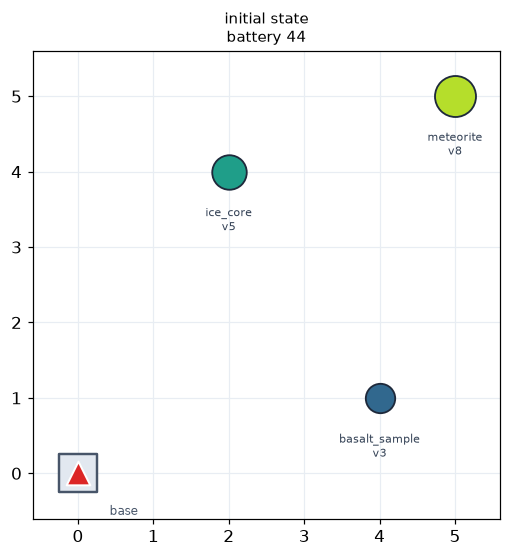

In [12]:
from world import build_world, ROVER, LANDER

world = build_world(battery=44)

print("Mission brief sent to the planner:\n")
print(" ", world.goal)
print("\nEntities:")
for name, e in world.entities.items():
    print(f"  {name:15s} kind={getattr(e, 'kind', '?'):14s} state={e.state.values}")

draw_grid(world, title="initial state")

## Step 2 — what *can* the rover do? (affordances)

Three action templates, each an `ActionSpec` with a **precondition** (the guard) and an **effect** (the state change):

- **`move(target)`** — step one grid cell toward a landmark (a sample or the base). *Precondition:* `battery > 0` and not already there. *Effect:* move one cell, `battery -= 1`.
- **`collect(sample)`** — pick a sample up. *Precondition:* standing on it **and** hands empty. *Effect:* `carrying = sample`.
- **`deposit(sample)`** — drop the carried sample at the base. *Precondition:* carrying it **and** standing on the base. *Effect:* the sample is banked.

Two consequences fall straight out of these guards and shape the whole problem:

1. **One sample at a time.** `collect` requires empty hands, and you can only empty them at the base — so **every sample is a separate round trip**.
2. **Battery is a hard budget.** `move` is the only thing that costs battery, and it can refuse.

`Environment.available_actions()` does the enumeration for us: it binds every spec to every legal target and keeps only those whose precondition currently holds.

In [13]:
# Legal actions from the starting state (only preconditions that currently hold)
print("Available actions right now:")
for a in world.available_actions():
    print("  ", a)

# The "physics" of the task: each sample is a round trip from the base.
def manhattan(ax, ay, bx, by):
    return abs(ax - bx) + abs(ay - by)

lx, ly = world.entity(LANDER).state["x"], world.entity(LANDER).state["y"]
print("\nRound-trip cost of each sample (base -> sample -> base):")
total = 0
for s in world.samples():
    rt = 2 * manhattan(lx, ly, s.state["x"], s.state["y"])
    total += rt
    print(f"  {s.name:15s} value {s.state['value']}  ->  {rt:2d} battery   "
          f"(value/battery = {s.state['value'] / rt:.2f})")
print(f"\n  fetch everything = {total} battery   |   rover starts with "
      f"{world.entity(ROVER).state['battery']}")
print("  => with a full tank it all fits; shrink the battery and the rover must choose.")

Available actions right now:
   rover.move(basalt_sample)
   rover.move(ice_core)
   rover.move(meteorite)

Round-trip cost of each sample (base -> sample -> base):
  basalt_sample   value 3  ->  10 battery   (value/battery = 0.30)
  ice_core        value 5  ->  12 battery   (value/battery = 0.42)
  meteorite       value 8  ->  20 battery   (value/battery = 0.40)

  fetch everything = 42 battery   |   rover starts with 44
  => with a full tank it all fits; shrink the battery and the rover must choose.


## Step 3 — describe the world to the language model

The model never sees Python objects. `describe(env)` flattens the world into JSON: the goal, every entity with its state, the spatial relations, and — crucially — an **`attribute_map`** that tells the model exactly which fields it is allowed to read (and their types). That map is the contract the synthesized objective must stay inside.

In [14]:
from lg_ompc import describe

description = build_world(battery=44)
desc = describe(description)

print("ATTRIBUTE MAP (the only fields the objective may read):")
for path, type_name in desc.attribute_map.items():
    print(f"  {path:28s}: {type_name}")

print("\nSpatial relations exposed to the model:")
for r in build_world(battery=44).compute_relations():
    print(f"  {r.source} -> {r.target}: {r.type} = {r.value}")

print("\n--- first 900 chars of the JSON payload ---\n")
print(desc.to_prompt_json()[:900], "...")

ATTRIBUTE MAP (the only fields the objective may read):
  rover.x                     : int
  rover.y                     : int
  rover.battery               : int
  rover.carrying              : NoneType
  lander.x                    : int
  lander.y                    : int
  basalt_sample.x             : int
  basalt_sample.y             : int
  basalt_sample.value         : int
  basalt_sample.collected     : bool
  basalt_sample.deposited     : bool
  ice_core.x                  : int
  ice_core.y                  : int
  ice_core.value              : int
  ice_core.collected          : bool
  ice_core.deposited          : bool
  meteorite.x                 : int
  meteorite.y                 : int
  meteorite.value             : int
  meteorite.collected         : bool
  meteorite.deposited         : bool

Spatial relations exposed to the model:
  rover -> lander: distance = 0.0
  rover -> basalt_sample: distance = 5.0
  rover -> ice_core: distance = 6.0
  rover -> meteorite: dis

## Step 4 — let the language model write the objective

Here is the language-guided part. We hand the model the mission brief and the attribute map, and ask it to return a single Python function:

```python
def evaluate_objective(world, history) -> float:
    # higher = more desirable
    ...
```

The model has to *infer* the trade-off from prose — "prefer the most valuable", "spend battery wisely", "don't strand the rover" — and encode it as numbers. We never tell it the round-trip costs or the single-carry rule; it has to reason about them from the state it can see.

If no API key is present we fall back to a hand-written objective so the rest of the notebook still runs. (A Jupyter kernel already runs an event loop, so we call the **async** synthesis API with `await`.)

In [15]:
from lg_ompc import compile_objective, synthesize_objective_async

# Battery-aware safety net, used only when there is no API key.
FALLBACK_OBJECTIVE = '''
def evaluate_objective(world, history):
    rover = world.entity("rover")
    lander = world.entity("lander")
    rx, ry = rover.state.get("x"), rover.state.get("y")
    lx, ly = lander.state.get("x"), lander.state.get("y")
    battery = rover.state.get("battery")
    carrying = rover.state.get("carrying")
    dist_home = abs(rx - lx) + abs(ry - ly)

    samples = [e for e in world.entities.values()
               if getattr(e, "kind", "") == "sample"]

    score = 0.0
    # Banked science is what ultimately counts.
    for s in samples:
        if s.state.get("deposited"):
            score += 100.0 * s.state.get("value")

    if carrying is not None:
        held = world.entity(carrying)
        score += 40.0 * held.state.get("value")  # good, but only realised at home
        score -= 2.0 * dist_home                  # so head for the base
    else:
        # Empty-handed: aim for the best sample we can still fetch AND return.
        best = None
        for s in samples:
            if s.state.get("deposited") or s.state.get("collected"):
                continue
            d_to = abs(rx - s.state.get("x")) + abs(ry - s.state.get("y"))
            d_back = abs(s.state.get("x") - lx) + abs(s.state.get("y") - ly)
            if d_to + d_back > battery:
                continue  # cannot fetch this and make it home; ignore it
            cand = 12.0 * s.state.get("value") - 1.5 * d_to
            if best is None or cand > best:
                best = cand
        if best is not None:
            score += best
        elif dist_home > 0:
            score -= 2.0 * dist_home  # nothing affordable: come home safely

    score -= 0.1 * len(history)
    return score
'''

spec = None
if HAS_API_KEY:
    print(f"Asking {os.environ.get('LLM_MODEL', 'gpt-5.2')} to synthesize an objective...\n")
    spec = await synthesize_objective_async(build_world(battery=44))
    objective_code = spec.code
    source = "LLM-synthesized"
else:
    print("No API key found - using the hand-written fallback objective.\n")
    objective_code = FALLBACK_OBJECTIVE
    source = "hand-written fallback"

objective = compile_objective(objective_code)
print(f"Objective source: {source}")

Asking gpt-5.2 to synthesize an objective...

Objective source: LLM-synthesized


In [16]:
# Inspect what the model produced (when it ran). Terms are its own explanation.
if spec is not None:
    print("The model decomposed its objective into weighted terms:\n")
    for t in spec.terms:
        print(f"  - {t.name:22s} (weight={t.weight:+.1f})  {t.rationale}")
    print("\nOverall rationale:\n ", spec.rationale)
    print("\n" + "=" * 70 + "\n")

print(objective_code)

The model decomposed its objective into weighted terms:

  - deposited_value        (weight=+200.0)  Primary objective: returned science. Strong terminal reward ensures depositing dominates other considerations.
  - collected_not_deposited_value (weight=+120.0)  Securing a sample is good progress even before deposit; encourages picking up when near a sample.
  - best_secured_bonus     (weight=+80.0)  Bias toward securing the highest-value sample first when battery is limited.
  - next_subgoal_distance_shaping (weight=+10.0)  Dense potential toward either lander (when carrying) or the best tradeoff sample; prevents myopic planner from stalling.
  - battery_return_margin  (weight=+6.0)  Avoid getting stranded: penalize states where battery is insufficient to return to lander; mild reward for positive margin.
  - battery_level          (weight=+0.2)  Tie-breaker encouraging efficiency without freezing progress.
  - effort                 (weight=+0.5)  Small penalty for taking extra actio

## Step 5 — does the objective rank states sensibly?

Before letting it drive, we sanity-check the objective by scoring a few hand-built states. We expect a clear ordering: **everything banked** ≫ **carrying a valuable sample near home** > **empty-handed at the start**. The objective runs inside a read-only sandbox (`evaluate`), so a buggy function can never mutate the world — at worst it scores `-inf` and that branch is ignored.

In [17]:
from lg_ompc import evaluate

# (a) the untouched start
start = build_world(battery=44)

# (b) carrying the meteorite, one cell from home
carrying = build_world(battery=30)
carrying.entity("rover").state["x"] = 1
carrying.entity("rover").state["y"] = 0
carrying.entity("rover").state["carrying"] = "meteorite"
carrying.entity("meteorite").state["collected"] = True
carrying.update()  # the carried sample rides along

# (c) all three samples banked
done = build_world(battery=10)
for s in done.samples():
    s.state["deposited"] = True

for label, env in [("start (empty, full battery)", start),
                   ("carrying meteorite near base", carrying),
                   ("all three banked", done)]:
    print(f"score({label:32s}) = {evaluate(objective, env, []):.2f}")

print("\nHigher is better -> the objective should prefer banked science, "
      "exactly what the planner will climb toward.")

score(start (empty, full battery)     ) = -15.20
score(carrying meteorite near base    ) = 1610.00
score(all three banked                ) = 3852.00

Higher is better -> the objective should prefer banked science, exactly what the planner will climb toward.


## Step 6 — hand the objective to the MPC controller

Now the discrete model-predictive loop takes over. At each step the `Controller`:

1. runs a finite-horizon **forward search** over the legal actions (this is the "predictive" part — it imagines a few moves ahead on *cloned* copies of the world),
2. **commits only the first action** of the best line it found,
3. lets the world change, then **replans from scratch**.

That "plan a little, commit one step, replan" cycle is exactly receding-horizon MPC. With a full battery we expect the rover to ferry all three samples home.

In [18]:
from lg_ompc import Controller

# The horizon is the planner's "look-ahead". It must be deep enough to *see* a
# milestone (reaching and collecting a sample) so the planner is willing to set
# off; the nearest sample here is ~6 steps away.
HORIZON = 6

mission = build_world(battery=44)
result = Controller(horizon=HORIZON, max_steps=80).run(mission, objective=objective)

banked = [s.name for s in mission.samples() if s.state.get("deposited")]
value = sum(s.state["value"] for s in mission.samples() if s.state.get("deposited"))
used = 44 - mission.entity(ROVER).state["battery"]

print("Executed plan:")
for i, a in enumerate(result.history, 1):
    print(f"  {i:2d}. {a}")

print(f"\nSamples returned : {banked}")
print(f"Scientific value : {value}")
print(f"Battery spent     : {used} / 44")
print(f"Mission complete  : {result.reached_goal}")

Executed plan:
   1. rover.move(basalt_sample)
   2. rover.move(basalt_sample)
   3. rover.move(ice_core)
   4. rover.move(ice_core)
   5. rover.move(ice_core)
   6. rover.move(basalt_sample)
   7. rover.move(meteorite)
   8. rover.move(meteorite)
   9. rover.move(meteorite)
  10. rover.move(meteorite)
  11. rover.collect(meteorite)
  12. rover.move(lander)
  13. rover.move(lander)
  14. rover.move(lander)
  15. rover.move(lander)
  16. rover.move(lander)
  17. rover.move(lander)
  18. rover.move(lander)
  19. rover.move(lander)
  20. rover.move(lander)
  21. rover.move(lander)
  22. rover.deposit(meteorite)
  23. rover.move(basalt_sample)
  24. rover.move(basalt_sample)
  25. rover.move(ice_core)
  26. rover.move(ice_core)
  27. rover.move(ice_core)
  28. rover.move(ice_core)
  29. rover.collect(ice_core)
  30. rover.move(lander)
  31. rover.move(lander)
  32. rover.move(lander)
  33. rover.move(lander)
  34. rover.move(lander)
  35. rover.move(lander)
  36. rover.deposit(ice_core)
  

### Watch the mission unfold

We replay the committed actions on a fresh world and snapshot it at every **collect** and **deposit** event. The faint red trail is the path travelled so far; a gold ring marks the sample currently in the rover's gripper.

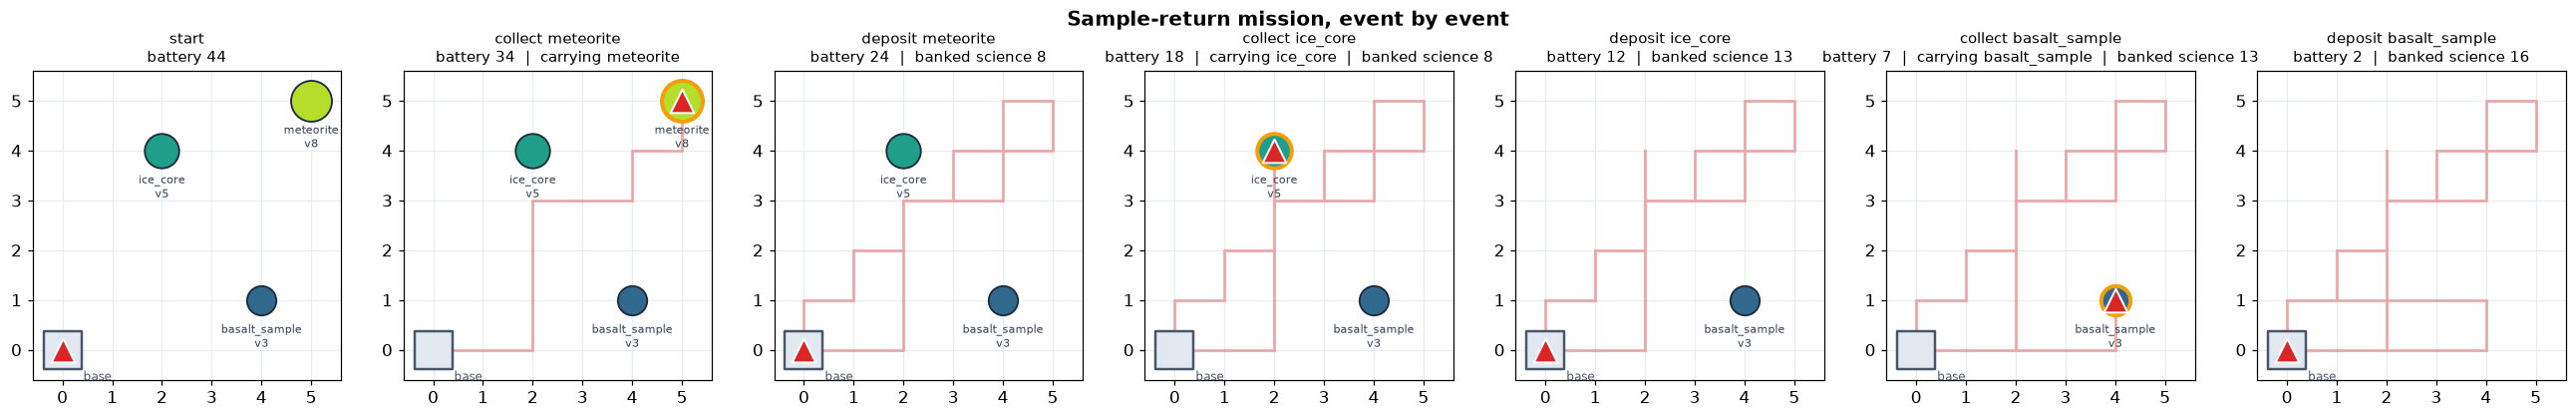

In [19]:
import copy

# Replay, capturing a frame at the start and after each collect/deposit event.
replay = build_world(battery=44)
path = [(replay.entity("rover").state["x"], replay.entity("rover").state["y"])]
frames = [(copy.deepcopy(replay), list(path), "start")]

for a in result.history:
    replay.apply(a)
    path.append((replay.entity("rover").state["x"], replay.entity("rover").state["y"]))
    if a.name in ("collect", "deposit"):
        frames.append((copy.deepcopy(replay), list(path), f"{a.name} {a.target}"))

cols = len(frames)
fig, axes = plt.subplots(1, cols, figsize=(3.4 * cols, 3.6))
if cols == 1:
    axes = [axes]
for ax, (frame, trail, label) in zip(axes, frames):
    draw_grid(frame, ax=ax, title=label, show_path=trail)
fig.suptitle("Sample-return mission, event by event", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

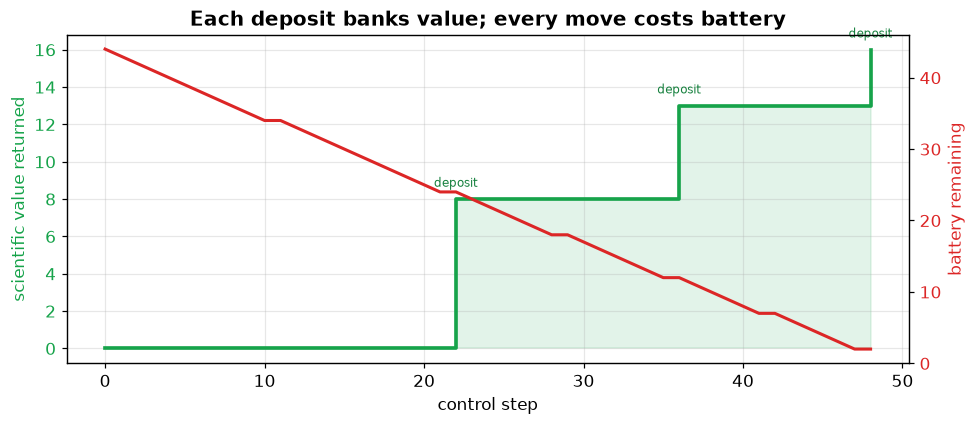

In [20]:
# Trace battery drain against science banked, step by step.
replay = build_world(battery=44)
steps = [0]
battery_trace = [replay.entity(ROVER).state["battery"]]
banked_trace = [0]

for i, a in enumerate(result.history, 1):
    replay.apply(a)
    steps.append(i)
    battery_trace.append(replay.entity(ROVER).state["battery"])
    banked_trace.append(sum(s.state["value"] for s in replay.samples()
                            if s.state.get("deposited")))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.step(steps, banked_trace, where="post", color="#16a34a", lw=2.4,
         label="science banked")
ax1.fill_between(steps, banked_trace, step="post", color="#16a34a", alpha=0.12)
ax1.set_xlabel("control step")
ax1.set_ylabel("scientific value returned", color="#16a34a")
ax1.tick_params(axis="y", labelcolor="#16a34a")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(steps, battery_trace, color="#dc2626", lw=2.0, label="battery")
ax2.set_ylabel("battery remaining", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")
ax2.set_ylim(0, 46)

# Mark deposit events where the green staircase jumps.
for i in range(1, len(banked_trace)):
    if banked_trace[i] > banked_trace[i - 1]:
        ax1.annotate("deposit", (steps[i], banked_trace[i]),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=8, color="#15803d")

ax1.set_title("Each deposit banks value; every move costs battery", weight="bold")
plt.tight_layout()
plt.show()

## Step 7 — the trade-off, made visible

This is where the language-guided objective earns its keep. We keep **the same objective** and **the same world layout**, and only shrink the battery. A hand-coded controller with a fixed plan would simply fail when it ran out of charge. Instead, the synthesized objective lets the planner *reason about the budget*: it quietly drops the trips it can't afford and secures the best samples it can.

Below we run the full controller at several battery levels and plot the scientific value it manages to bring home.

battery 12  ->  value  0  samples []  (goal reached: False)
battery 18  ->  value  0  samples []  (goal reached: False)
battery 22  ->  value  8  samples ['meteorite']  (goal reached: False)
battery 32  ->  value 13  samples ['ice_core', 'meteorite']  (goal reached: False)
battery 44  ->  value 16  samples ['basalt', 'ice_core', 'meteorite']  (goal reached: True)


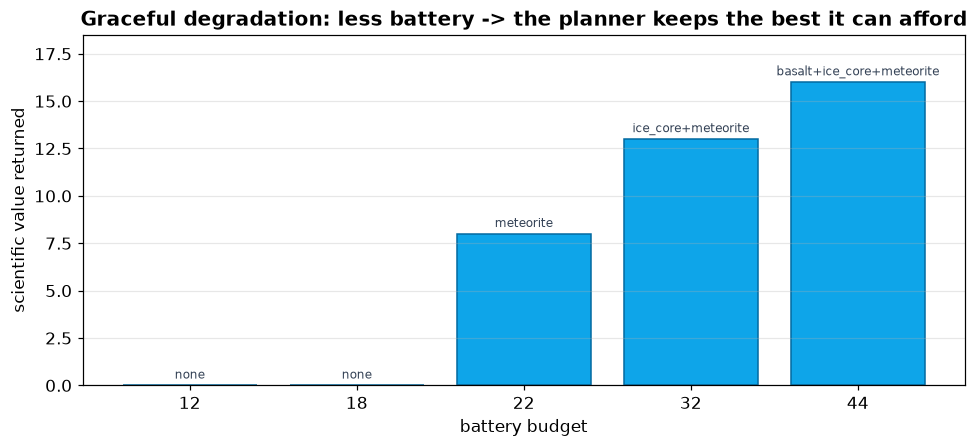

In [21]:
# Same objective, same map, shrinking battery budgets. (Takes a moment: each
# budget runs the full controller.)
budgets = [12, 18, 22, 32, 44]
returned_value = []
returned_names = []

for batt in budgets:
    env = build_world(battery=batt)
    r = Controller(horizon=HORIZON, max_steps=80).run(env, objective=objective)
    names = [s.name.replace("_sample", "") for s in env.samples()
             if s.state.get("deposited")]
    returned_value.append(sum(s.state["value"] for s in env.samples()
                              if s.state.get("deposited")))
    returned_names.append(names)
    print(f"battery {batt:2d}  ->  value {returned_value[-1]:2d}  "
          f"samples {names}  (goal reached: {r.reached_goal})")

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar([str(b) for b in budgets], returned_value,
              color="#0ea5e9", edgecolor="#0369a1")
for bar, names in zip(bars, returned_names):
    label = "+".join(names) if names else "none"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            label, ha="center", va="bottom", fontsize=8, color="#334155")
ax.set_xlabel("battery budget")
ax.set_ylabel("scientific value returned")
ax.set_title("Graceful degradation: less battery -> the planner keeps the best it can afford",
             weight="bold")
ax.set_ylim(0, max(returned_value) + 2.5)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Recap — what this example showed

The hydration notebook proved the pipeline *runs*. This one shows why the language-guided objective is worth the trouble:

- **Multiple competing objects.** Three samples, one rover — the objective has to *prioritise*, not just chase a single goal.
- **A real constraint.** The battery turns the task into a tiny routing/knapsack problem. The single-carry rule (every sample is a round trip) is never stated to the model; it has to read it out of the preconditions' consequences.
- **Affordance vs. desirability stayed separate.** `world.py` only ever says what is *possible*. Which samples to grab, in what order, and when to head home all came from the synthesized objective.
- **Graceful degradation.** The same objective, run against shrinking battery budgets, kept the most valuable affordable samples instead of failing outright — behaviour we never coded by hand.

### The reusable recipe

To model *your own* world with this framework you write only three things — exactly what `world.py` contains:

1. **`Entity` subclasses** with state and the action specs they offer (`outgoing_actions` / `incoming_actions`).
2. **`ActionSpec`s** — a `precondition` (the affordance guard) and an `effect` (the state change) per verb.
3. An **`Environment`** that wires entities together, optionally exposes `compute_relations()`, and defines `is_terminal()`.

Everything else — serialization, LLM objective synthesis, the sandbox, the forward-search planner, and the receding-horizon controller — is provided by `lg_ompc` and reused unchanged.

> **Try it yourself:** move a sample, add a fourth one, change the mission brief to *"only the single most valuable sample matters"*, or re-run with a different model. The world stays fixed; the language reshapes the behaviour.